## Infos
- Implement Wandb
- Feature engineering:
    - **lags**: y(t−1), y(t−2), y(t−24), y(t−168) (hour/day/week patterns)
    - **difference features**: y(t)−y(t−1), y(t)−y(t−24) etc.
    - **rolling stats**: mean / std / min / max / slope of last 6h / 24h / 7d
    - **volatility/stability**: rolling std, MAD, coefficient of variation
    - **time-of-use effects**: weekend flag, maybe holidays, sin/cos encoding of time of year (cyclic)
    - **external drivers**: make use of causal context (like temperature, humidity, solar irradiance)
    - **reduce data**: remove night timestamps, due to DR-flags = 0
- Improve training
    - gradient clipping
    - early stopping
    - warmup
    - dropout
    - weight decay
    - checkpoints

- TCN remove "causal flag" (something causal dilation..)
    - set causal = False for leakage from future (needed for accuracy)

Questions:
- Does it make sense to also consider "future" data?
    - Makes sense as long as the real-use case also includes both

Install all necessary libraries.

In [35]:
%pip install torch
%pip install pandas
%pip install numpy
%pip install imblearn
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129
%pip install wandb
%pip install holidays

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 28.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Import all necessary libraries.

In [36]:
import pandas as pd
import numpy as np
import os
import wandb
import datetime
import holidays
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader
from imblearn.metrics import geometric_mean_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import sys
sys.path.append('../src/evaluation')

from comp_metrics import evaluate_all_metrics

In [3]:
os.environ["WANDB_API_KEY"] = "3aaf9f796df65417b3f5f8560b43875171b55805"

In [4]:
wandb.login()

wandb: Currently logged in as: fabian-dubach (fabian-dubach-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Set seed for reproducibility.

In [5]:
torch.manual_seed(42)
np.random.seed(42)

In [6]:
df_train = pd.read_csv("../data/regression/regression-train.csv")
df_test = pd.read_csv("../data/regression/regression-test.csv")

In [7]:
print(f"Dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

Dataset shape: (105120, 7)

Columns: ['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW', 'Demand_Response_Flag', 'Demand_Response_Capacity_kW']


In [8]:
df_train.head()

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


# Feature Engineering

## Temporal Components

`hour_of_day`

**Best**: encode as cyclic using sine/cosine (captures continuity between 23→0).
`sin_hour = sin(2π * hour / 24)`, `cos_hour = cos(2π * hour / 24)`.

**Optional**: also include a small set of one-hot bins like is_night, is_business_hours if behavior is strongly segmented.

**Why**: One-hot loses the notion that 23:00 and 0:00 are adjacent.

**WARNING!**: Cyclic may not be the best option in our usecase, as we remove some timestamps per day to only keep relevant data

`day_of_week` (0–6)

Good candidate for one-hot (7 categories).

**Alternative**: cyclic encoding (sine/cos) if you prefer continuous representation; or both (OHE + cyc) if model benefits.

**Recommendation**: OHE is fine for most models and interpretable.

`day_of_month` (1–31)

Usually NOT good for one-hot — 31 columns adds complexity and many values behave similarly.

**Better**:

use `day_of_month` as numeric (may be noisy),

or derive features: `is_month_start`, `is_month_end`, `week_of_month`, `day_bucket` (e.g., 1–7, 8–14, ...),

or cyclic encode `day_of_month` if you think monthly periodicity matters (but monthly patterns often weak).

`day_of_year` / `month`

**Month (1–12)**: one-hot is fine (12 categories) or cyclic encoding (seasonality).

**Day_of_year (1–365)**: use Fourier terms (multiple sine/cos pairs) to model seasonal cycles rather than 365 OHE columns.

`is_weekend`, `is_holiday`

**One-hot / binary** — very useful. If holiday types matter, create `holiday_type` and consider OHE (low cardinality).

In [ ]:
australian_holidays = holidays.AU()

def add_time_features(df):
    df['Timestamp_Local'] = pd.to_datetime(df['Timestamp_Local']) # dont use in input (feature)
    df['hour'] = df['Timestamp_Local'].dt.hour # normally cyclic but in our case 
    df['minute'] = df['Timestamp_Local'].dt.minute
    df['day_of_month'] = df['Timestamp_Local'].dt.day
    df['day'] = df['Timestamp_Local'].dt.day  # Same as day_of_month
    df['month'] = df['Timestamp_Local'].dt.month
    df['day_of_week'] = df['Timestamp_Local'].dt.dayofweek
    df['is_weekend'] = df['Timestamp_Local'].dt.dayofweek >= 5
    df['is_holiday'] = df['Timestamp_Local'].dt.date.apply(lambda x: x in australian_holidays)
    return df

In [10]:
df_train = add_time_features(df_train)

### Remove Entries over Night

Previous data analysis has shown, that data over night is constant and never part of any DR events

Hour values are now from 6 AM to 7 PM, will be normalized later by scalar.

In [ ]:
df_train = df_train[df_train['hour'].between(6, 19)].copy()

In [ ]:
# HINT: dont use site as a feature (only to calculate other features based on past timestamps)

continuous_feature_columns = ['Dry_Bulb_Temperature_C', 
                   'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW']
categorical_feature_columns = ['Demand_Response_Flag', 'hour', 'minute', 'day_of_month', 
                   'day', 'month', 'day_of_week', 'is_weekend', 'is_holiday']

target_column = 'Demand_Response_Capacity_kW'

In [13]:
print(continuous_feature_columns)
print(target_column)

['Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW']
Demand_Response_Capacity_kW


Convert to numpy array and reshape the target variable
- **Why convert?**: NumPy arrays are faster and more memory-efficient for numerical computations.
- **Why reshape?**: Reshape to make feature and target variable the same size to make them comparable (from 1D to 2D).

In [14]:
X_continuous = df_train[continuous_feature_columns].values # Convert to numpy array
X_categorical = df_train[categorical_feature_columns].values # Convert to numpy array
y = df_train[target_column].values.reshape(-1, 1) # Convert to numpy array and reshape

In [15]:
print(f"Continuous feature shape: {X_continuous.shape}")
print(f"Categorical feature shape: {X_categorical.shape}")
print(f"Target shape: {y.shape}")

Continuous feature shape: (105120, 3)
Categorical feature shape: (105120, 8)
Target shape: (105120, 1)


Scale features
- **Why scaling?**: Features with larger values dominate the learning process! (Gradient Descent Gets Confused, Exploding/Vanishing Gradients, Unfair Feature Importance)
- Benefits: All features have equal influence initially, Gradients are stable and balanced, Optimizer converges much faster, Model learns actual patterns (not just scales)

In [16]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_continuous)
y = scaler_y.fit_transform(y)

Concatenate the unscaled and the scaled features together.

In [17]:
X = np.concatenate([X_scaled, X_categorical], axis=1)

In [18]:
print(f"Continuous feature shape: {X.shape}")
print(X[0])

Continuous feature shape: (105120, 11)
[ 0.83262963 -0.75734429 -0.51225014  0.          0.          0.
  0.          1.          1.          1.          1.        ]


Split data -> Split the data into training and validation.

In [19]:
# Assuming: Site_A → 0, Site_B → 1, Site_C → 2
train_mask = np.isin(X[:, 3], [0, 1])  # Site_A and Site_B
val_mask = X[:, 3] == 2                # Site_C

X_train = X[train_mask]
X_val = X[val_mask]
y_train = y[train_mask]
y_val = y[val_mask]

In [20]:
print(len(X_train))
print(len(y_train))
print(len(X_val))
print(len(y_val))

70080
70080
35040
35040


In [21]:
config = {
    # Model hyperparameters
    'input_size': X_train.shape[1],
    'hidden_size': 64,
    'num_layers': 2,
    'output_size': 1,
    'sequence_length': 672, # 1 week
    
    # Training hyperparameters
    'learning_rate': 0.0001,
    'batch_size': 32,
    'num_epochs': 50,
    'gradient_clip_val': 1.0,
    'optimizer': 'Adam',
    'loss_function': 'MSE',
    
    # Model architecture
    'model_type': 'RNN'
}

Create sequences to create a "sliding window" for the RNN architechture to predict the current hidden state based on the past values.

In [22]:
def create_sequences(X, y, seq_length=config['sequence_length']):
    sequences_X = []
    sequences_y = []
    
    for i in range(len(X) - seq_length):
        sequences_X.append(X[i:i+seq_length])
        sequences_y.append(y[i+seq_length])
    
    return np.array(sequences_X), np.array(sequences_y)

In [23]:
X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)

In [24]:
print(f"Training sequences shape: {X_train_seq.shape}, Training targets shape: {y_train_seq.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}, Validation targets shape: {y_val_seq.shape}")

Training sequences shape: (69408, 672, 11), Training targets shape: (69408, 1)
Validation sequences shape: (34368, 672, 11), Validation targets shape: (34368, 1)


Create "class PowerDataset" for converting numpy arrays to PyTorch tensors (required for PyTorch models).
- __len__: Tells PyTorch how many samples are in the dataset
- __getitem__: Allows indexing

In [25]:
class PowerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X) # Convert numpy → PyTorch tensor
        self.y = torch.FloatTensor(y) # Convert numpy → PyTorch tensor
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Create DataLoader -> DataLoader's job: Efficiently load data in batches during training

In [26]:
train_dataset = PowerDataset(X_train_seq, y_train_seq)
val_dataset = PowerDataset(X_val_seq, y_val_seq)

batch_size = config['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Shuffle training data to reduce bias throughout the year
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Create a simple RNN architecture.

Why not use nn.RNN: nn.RNN is just the recurrent layer - it's not a complete model. You need additional components to make predictions.

In [27]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, 
                          batch_first=True, nonlinearity='relu')
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.rnn(x, h0)
        # Take the last time step
        out = out[:, -1, :]
        out = self.fc(out)
        return out

Define hyperparameters for the model.

Define cuda as the device to make the training possible to the GPU.

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Generate model.

In [29]:
model = SimpleRNN(config['input_size'], config['hidden_size'], config['num_layers'], config['output_size']).to(device)
print(f"Model architecture:\n{model}")

Model architecture:
SimpleRNN(
  (rnn): RNN(11, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Setup the loss function and optimizer.

In [30]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])

In [31]:
# Start a new wandb run to track this script.
wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="fabian-dubach-hochschule-luzern",
    # Set the wandb project where this run will be logged.
    project="AICOMP_Flextrack",
    # Name this run
    name=config['model_type'].lower() + "-regression-v1",
    # Track hyperparameters and run metadata.
    config=config
)

print("WandB initialized successfully!")

WandB initialized successfully!


Training.

In [32]:
train_sites = le.inverse_transform(X_train_seq[:, -1, 3].astype(int))
val_sites = le.inverse_transform(X_val_seq[:, -1, 3].astype(int))

train_building_power = X_train_seq[:, -1, 2]
val_building_power = X_val_seq[:, -1, 2]

train_demand_flags = X_train_seq[:, -1, 4].astype(int)
val_demand_flags = X_val_seq[:, -1, 4].astype(int)

print(f"Training samples: {len(train_sites)}")
print(f"Validation samples: {len(val_sites)}")

Training samples: 69408
Validation samples: 34368


In [33]:
"""
Simplified training loop - only 4 aggregated metrics
"""

train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...")
for epoch in range(config['num_epochs']):
    
    # ============== TRAINING ==============
    model.train()
    train_loss = 0
    train_preds_list = []
    train_targets_list = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), config['gradient_clip_val'])
        optimizer.step()
        
        train_loss += loss.item()
        
        # Store predictions and targets for metrics
        train_preds_list.append(outputs.detach().cpu().numpy())
        train_targets_list.append(y_batch.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Concatenate training predictions and targets
    train_preds = np.concatenate(train_preds_list)
    train_targets = np.concatenate(train_targets_list)
    
    # Inverse transform to original scale
    train_preds_original = scaler_y.inverse_transform(train_preds)
    train_targets_original = scaler_y.inverse_transform(train_targets)
    
    # Calculate training metrics
    train_metrics = evaluate_all_metrics(
        y_true=train_targets_original.flatten(),
        y_pred=train_preds_original.flatten(),
        site_labels=train_sites,
        building_power=train_building_power,
        demand_flags=train_demand_flags
    )
    
    # ============== VALIDATION ==============
    model.eval()
    val_loss = 0
    val_preds_list = []
    val_targets_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            
            # Store predictions and targets for metrics
            val_preds_list.append(outputs.cpu().numpy())
            val_targets_list.append(y_batch.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Concatenate validation predictions and targets
    val_preds = np.concatenate(val_preds_list)
    val_targets = np.concatenate(val_targets_list)
    
    # Inverse transform to original scale
    val_preds_original = scaler_y.inverse_transform(val_preds)
    val_targets_original = scaler_y.inverse_transform(val_targets)
    
    # Calculate validation metrics
    val_metrics = evaluate_all_metrics(
        y_true=val_targets_original.flatten(),
        y_pred=val_preds_original.flatten(),
        site_labels=val_sites,
        building_power=val_building_power,
        demand_flags=val_demand_flags
    )
    
    # ============== WANDB LOGGING ==============
    wandb.log({
        'epoch': epoch,
        'train/loss': train_loss,
        'val/loss': val_loss,
        'learning_rate': optimizer.param_groups[0]['lr'],
        
        # Training metrics
        'train/nmae_range': train_metrics['nmae_range'],
        'train/nmae_mean': train_metrics['nmae_mean'],
        'train/nrmse_range': train_metrics['nrmse_range'],
        'train/nrmse_mean': train_metrics['nrmse_mean'],
        'train/geometric_mean_score': train_metrics['geometric_mean_score'],
        'train/f1_score': train_metrics['f1_score'],
        
        # Validation metrics
        'val/nmae_range': val_metrics['nmae_range'],
        'val/nmae_mean': val_metrics['nmae_mean'],
        'val/nrmse_range': val_metrics['nrmse_range'],
        'val/nrmse_mean': val_metrics['nrmse_mean'],
        'val/geometric_mean_score': val_metrics['geometric_mean_score'],
        'val/f1_score': val_metrics['f1_score'],
    })
    
    # ============== CONSOLE OUTPUT ==============
    if (epoch + 1) % 10 == 0:
        print(f'\nEpoch [{epoch+1}/{config["num_epochs"]}]')
        print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        print(f'Train - NMAE(range): {train_metrics["nmae_range"]:.2f}% | '
              f'NMAE(mean): {train_metrics["nmae_mean"]:.2f}% | '
              f'NRMSE(range): {train_metrics["nrmse_range"]:.2f}% | '
              f'NRMSE(mean): {train_metrics["nrmse_mean"]:.2f}%')
        print(f'Train - GeoMean: {train_metrics["geometric_mean_score"]:.4f} | '
              f'F1: {train_metrics["f1_score"]:.4f}')
        print(f'Val   - NMAE(range): {val_metrics["nmae_range"]:.2f}% | '
              f'NMAE(mean): {val_metrics["nmae_mean"]:.2f}% | '
              f'NRMSE(range): {val_metrics["nrmse_range"]:.2f}% | '
              f'NRMSE(mean): {val_metrics["nrmse_mean"]:.2f}%')
        print(f'Val   - GeoMean: {val_metrics["geometric_mean_score"]:.4f} | '
              f'F1: {val_metrics["f1_score"]:.4f}')
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

wandb.finish()
print("\nTraining completed!")

Starting training...

Epoch [10/50]
Train Loss: 0.0097 | Val Loss: 2.6566
Train - NMAE(range): 39.66% | NMAE(mean): 0.00% | NRMSE(range): 132.93% | NRMSE(mean): 0.00%
Train - GeoMean: 0.4898 | F1: 0.0183
Val   - NMAE(range): 27.21% | NMAE(mean): 124.66% | NRMSE(range): 157.26% | NRMSE(mean): 720.53%
Val   - GeoMean: 0.6669 | F1: 0.1579

Epoch [20/50]
Train Loss: 0.0077 | Val Loss: 2.6224
Train - NMAE(range): 34.42% | NMAE(mean): 0.00% | NRMSE(range): 118.71% | NRMSE(mean): 0.00%
Train - GeoMean: 0.4839 | F1: 0.0188
Val   - NMAE(range): 28.71% | NMAE(mean): 131.57% | NRMSE(range): 156.24% | NRMSE(mean): 715.88%
Val   - GeoMean: 0.6661 | F1: 0.2517

Epoch [30/50]
Train Loss: 0.0067 | Val Loss: 2.6401
Train - NMAE(range): 30.69% | NMAE(mean): 0.00% | NRMSE(range): 110.26% | NRMSE(mean): 0.00%
Train - GeoMean: 0.4562 | F1: 0.0157
Val   - NMAE(range): 25.45% | NMAE(mean): 116.61% | NRMSE(range): 156.77% | NRMSE(mean): 718.29%
Val   - GeoMean: 0.6666 | F1: 0.0980

Epoch [40/50]
Train Loss: 0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



Epoch [50/50]
Train Loss: 0.0053 | Val Loss: 2.6509
Train - NMAE(range): 23.97% | NMAE(mean): 0.00% | NRMSE(range): 98.62% | NRMSE(mean): 0.00%
Train - GeoMean: 0.4683 | F1: 0.0171
Val   - NMAE(range): 26.70% | NMAE(mean): 122.35% | NRMSE(range): 157.09% | NRMSE(mean): 719.76%
Val   - GeoMean: 0.6660 | F1: 0.1841


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/f1_score,▄▁▄▂▅▆▅▃▆▆▄▄▄▆▅▄▇▅▆▃▆▃▅▃▅▃▃▄▆▄▆▇▆█▃▆▃▃▅▄
train/geometric_mean_score,▁▄▁▆▂▅▄▇▆▄▄▄▆▃▆▄▅▂▂▅▄▂▅▂▃▃▅▄▄▇▅█▂▅▆▃▄▃▄▄
train/loss,█▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/nmae_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/nmae_range,█▆▆▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
train/nrmse_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/nrmse_range,█▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
val/f1_score,▁▂▁▁▃▂▅▄▅▄▃▁▁▂▄██▃▅▄▁▁▅▃▇▅▇▄▁▆▂▆▆▃▁▄▃▁▂▅
+6,...



Training completed!


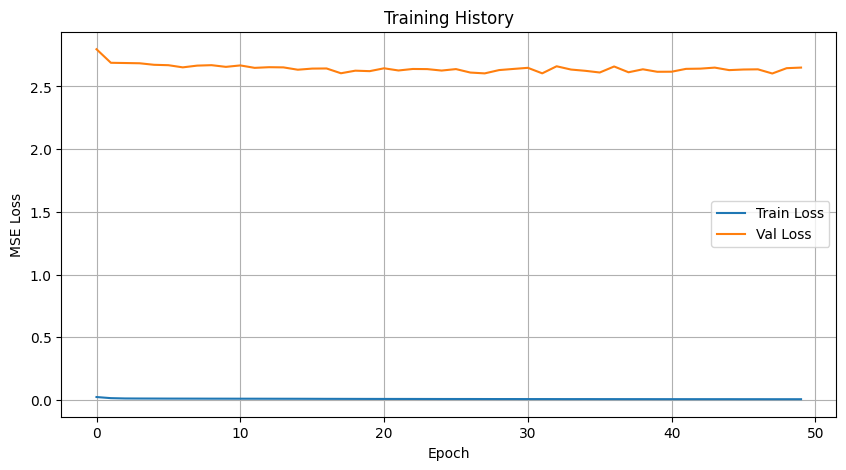

In [34]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)

# Make predictions on validation set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Inverse transform predictions
preds_original = scaler_y.inverse_transform(all_preds)
targets_original = scaler_y.inverse_transform(all_targets)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score

mse = mean_squared_error(targets_original, preds_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_original, preds_original)
r2 = r2_score(targets_original, preds_original)

# Normalized metrics (using mean of non-zero values)
targets_nonzero = targets_original[targets_original > 0]
mean_target_nonzero = np.mean(targets_nonzero) if len(targets_nonzero) > 0 else 1.0
normalized_mae = mae / mean_target_nonzero
normalized_rmse = rmse / mean_target_nonzero

# Geometric Mean Score
geometric_mean_score = np.sqrt(mae * rmse)

# F1 Score - Calculate from validation split
# Access the validation data from your original dataframe split
# Assuming you have val_data or can recreate the validation indices
try:
    # Get the validation data indices (you need to have saved these during train/val split)
    # Method 1: If you have access to val_data dataframe
    val_dr_flags = val_dataset['Demand_Response_Flag'].values
    
    # Filter to only DR events (where capacity should be non-zero)
    dr_mask = val_dr_flags != 0
    targets_dr = targets_original[dr_mask]
    preds_dr = preds_original[dr_mask]
    
    # Binary classification: predicted capacity correctly as zero/non-zero
    targets_binary = (targets_dr > 0).astype(int)
    preds_binary = (preds_dr > 0).astype(int)
    f1_dr = f1_score(targets_binary, preds_binary)
    
    print(f"F1 Score (DR Capacity only): {f1_dr:.4f} ({f1_dr*100:.2f}%)")
except:
    # Fallback: Calculate F1 on all validation data (zero vs non-zero)
    targets_binary = (targets_original > 0).astype(int)
    preds_binary = (preds_original > 0.5).astype(int)
    f1_all = f1_score(targets_binary, preds_binary)
    print(f"F1 Score (all validation data): {f1_all:.4f} ({f1_all*100:.2f}%)")

print(f"\nValidation Metrics:")
print(f"RMSE: {rmse:.4f} kW")
print(f"MAE: {mae:.4f} kW")
print(f"Normalized MAE: {normalized_mae:.4f}")
print(f"Normalized RMSE: {normalized_rmse:.4f}")
print(f"Geometric Mean Score: {geometric_mean_score:.4f}")
print(f"R2 Score: {r2:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(targets_original, preds_original, alpha=0.5, s=1)
plt.plot([targets_original.min(), targets_original.max()], 
         [targets_original.min(), targets_original.max()], 'r--', lw=2)
plt.xlabel('Actual Power Consumption (kW)')
plt.ylabel('Predicted Power Consumption (kW)')
plt.title('Predictions vs Actual')
plt.grid(True)

plt.subplot(1, 2, 2)
sample_size_lower = 200
sample_size_upper = 500
plt.plot(targets_original[sample_size_lower:sample_size_upper], label='Actual', alpha=0.7)
plt.plot(preds_original[sample_size_lower:sample_size_upper], label='Predicted', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Power Consumption (kW)')
plt.title(f'Sample Predictions (first {sample_size_upper-sample_size_lower} points)')
plt.legend()
plt.grid(True)